In [17]:
import numpy as np
import pandas as pd
import os


In [ ]:
directory_path = "/Users/benvyshedskiy/Downloads/IP_Data_Batches"

batch_folders = [
    f
    for f in os.listdir(directory_path)
    if os.path.isdir(os.path.join(directory_path, f))
]

interaction_files = []

for folder in batch_folders:
    file = directory_path+"/"+folder+"/"+"DE_all_v2_combined.csv"
    interaction_files.append(file)

['/Users/benvyshedskiy/Downloads/IP_Data_Batches/batch8/DE_all_v2_combined.csv', '/Users/benvyshedskiy/Downloads/IP_Data_Batches/batch6/DE_all_v2_combined.csv', '/Users/benvyshedskiy/Downloads/IP_Data_Batches/batch7/DE_all_v2_combined.csv', '/Users/benvyshedskiy/Downloads/IP_Data_Batches/batch9/DE_all_v2_combined.csv', '/Users/benvyshedskiy/Downloads/IP_Data_Batches/batch10/DE_all_v2_combined.csv', '/Users/benvyshedskiy/Downloads/IP_Data_Batches/batch11/DE_all_v2_combined.csv', '/Users/benvyshedskiy/Downloads/IP_Data_Batches/batch2/DE_all_v2_combined.csv', '/Users/benvyshedskiy/Downloads/IP_Data_Batches/batch5/DE_all_v2_combined.csv', '/Users/benvyshedskiy/Downloads/IP_Data_Batches/batch4/DE_all_v2_combined.csv', '/Users/benvyshedskiy/Downloads/IP_Data_Batches/batch14/DE_all_v2_combined.csv', '/Users/benvyshedskiy/Downloads/IP_Data_Batches/batch13/DE_all_v2_combined.csv', '/Users/benvyshedskiy/Downloads/IP_Data_Batches/batch12/DE_all_v2_combined.csv', '/Users/benvyshedskiy/Downloads/IP

In [ ]:
batch_data_combined = pd.concat(
    [pd.read_csv(file) for file in interaction_files], ignore_index=True
)
batch_data_combined = batch_data_combined.dropna(subset=["protein", "bait_id"])

/var/folders/_r/h4fm36fx2z14pzyxd4p2zqp80000gn/T/ipykernel_13477/3795220366.py:2: DtypeWarning: Columns (0: bait_id) have mixed types. Specify dtype option on import or set low_memory=False.
  [pd.read_csv(file) for file in interaction_files], ignore_index=True


In [ ]:
mmc2 = pd.read_excel("/Users/benvyshedskiy/Documents/GitHub/ESM_embedding_trickery/data/mmc2.xlsx",header = 1)
batch_data_combined = batch_data_combined[
    batch_data_combined["bait_id"].isin(mmc2["Fragment ID"])
]

In [40]:
duplicate_rows = batch_data_combined[batch_data_combined.duplicated(subset=["protein", "bait_id"], keep=False)]

In [44]:
duplicate_rows.sort_values(by=["protein","bait_id"]).head()

,log2FC,FDR,significant,is_library,is_target_bait,n_obs_target,detection_driven,protein,condition,plate,position,bait_id
10996272,0.215928,0.998095,False,False,False,0,False,A0A096LP01,plate1_D8,plate1,D8,AMD16557.1.14.1
20263006,-0.550606,0.884651,False,False,False,0,False,A0A096LP01,plate5_D8,plate5,D8,AMD16557.1.14.1
11036597,0.417907,0.872262,False,False,False,0,False,A0A096LP01,plate1_E12,plate1,E12,AP_000286.1.1
20320921,-1.117315,0.622559,False,False,False,0,False,A0A096LP01,plate5_E12,plate5,E12,AP_000286.1.1
11222092,0.057906,0.999625,False,False,False,0,False,A0A096LP01,plate1_G11,plate1,G11,AP_000535.1.1


In [48]:
batch_data_combined["linear_fc"] = np.exp2(batch_data_combined["log2FC"])
interaction_matrix = (
    batch_data_combined.pivot_table(
        index="protein",
        columns="bait_id",
        values="linear_fc",
        fill_value=0.0,
        aggfunc="median",  # Use 'max' or 'mean' if duplicate bait-prey pairs exist
    )
    .reset_index()
    .rename(columns={"protein": "prey"})
)

#interaction_matrix.columns.name = None

In [50]:
print(interaction_matrix.head())

bait_id          prey  A0A023T7J3.1  A0A023T7J3.5  A0A023T7J3.6  A0A059WD65.1  \
0        A0A022WUV6.1      0.000000      0.000000      0.000000           0.0   
1        A0A023T7J3.1   2531.812593      0.000000      0.000000           0.0   
2        A0A023T7J3.2      0.000000      0.000000      0.000000           0.0   
3        A0A023T7J3.5      0.000000   4009.422346      0.488149           0.0   
4        A0A023T7J3.6      0.000000      0.000000   1474.048896           0.0   

bait_id  A0A059WD72.2  A0A059WD79.1  A0A059WD93.1  A0A059WDA5.1  A0A059WDB0.1  \
0            0.000000           0.0           0.0           0.0           0.0   
1            0.000000           0.0           0.0           0.0           0.0   
2            0.000000           0.0           0.0           0.0           0.0   
3            1.083757           0.0           0.0           0.0           0.0   
4            0.727169           0.0           0.0           0.0           0.0   

bait_id  ...  YP_950477.1.

In [69]:
average_intensities_bait = []
for bait in set(list(batch_data_combined["bait_id"])):
    average_intensities_bait.append(sum(list(interaction_matrix[bait]))/len(interaction_matrix))

In [66]:
average_intensities_prey = []
for prey in set(list(batch_data_combined["protein"])):
    average_intensities_prey.append(sum(list(interaction_matrix[interaction_matrix["prey"]==prey].iloc[0])[1:len(interaction_matrix.columns)])/len(interaction_matrix))

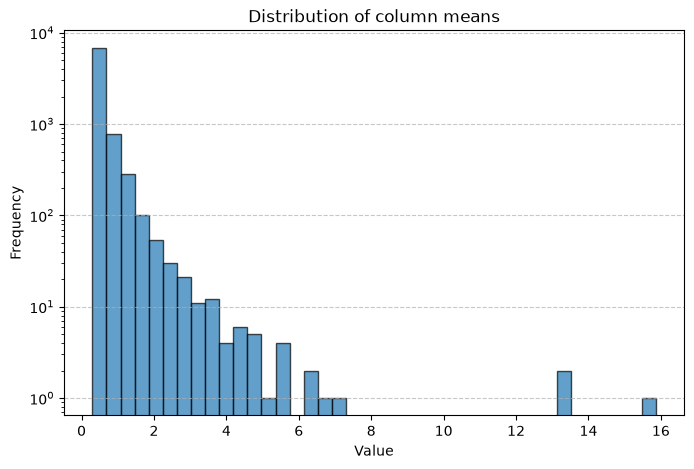

In [72]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))
plt.hist(average_intensities_bait, bins=40,log =True, edgecolor="black", alpha=0.7)
plt.title("Distribution of column means")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

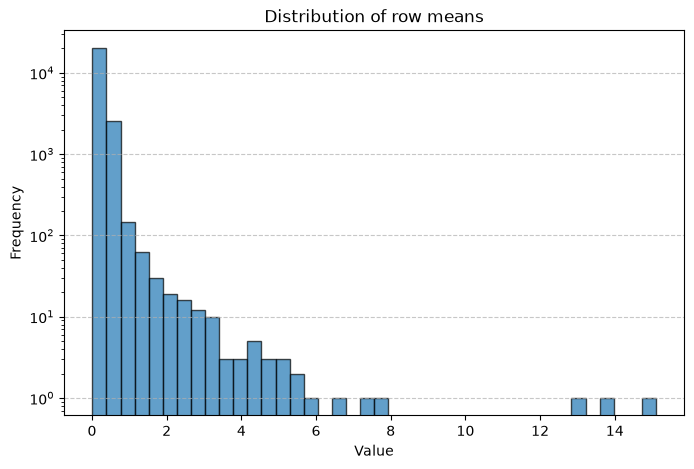

In [73]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))
plt.hist(average_intensities_prey, bins=40,log =True, edgecolor="black", alpha=0.7)
plt.title("Distribution of row means")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

In [ ]:
sum(list(interaction_matrix[interaction_matrix["prey"]=="P15880"].iloc[0])[1:len(interaction_matrix.columns)])/len(interaction_matrix)

np.float64(0.44565828045123107)

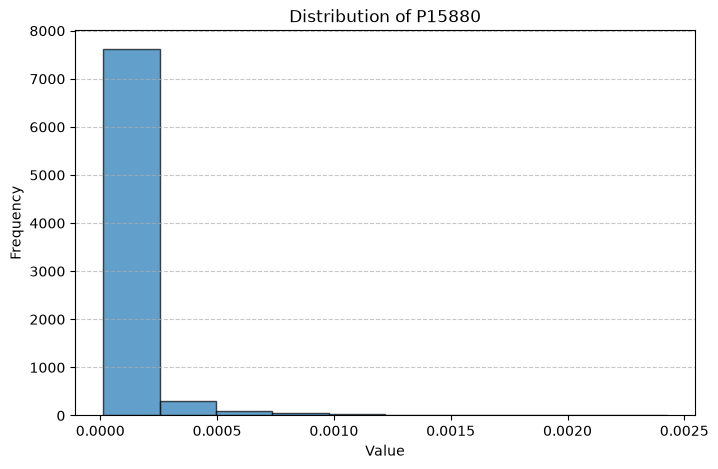

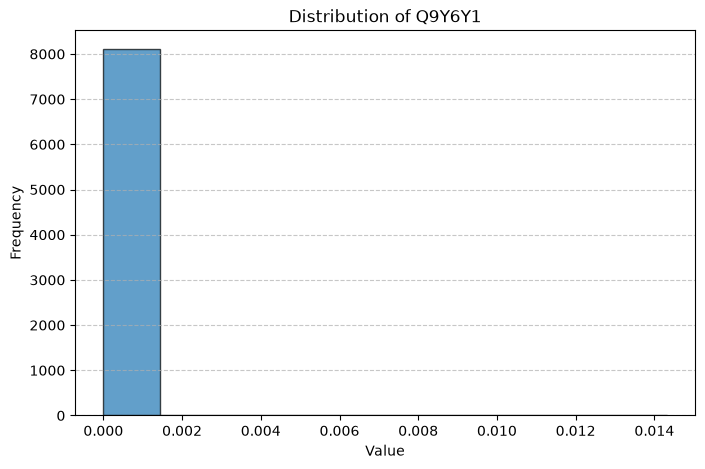

In [81]:
list_1 = [i/sum(list(interaction_matrix[interaction_matrix["prey"]=="P15880"].iloc[0])[1:len(interaction_matrix.columns)]) for i in list(interaction_matrix[interaction_matrix["prey"]=="P15880"].iloc[0])[1:len(interaction_matrix.columns)]]
plt.figure(figsize=(8, 5))
plt.hist(list_1, bins=10,log =False, edgecolor="black", alpha=0.7)
plt.title("Distribution of P15880")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

list_2 = [i/sum(list(interaction_matrix[interaction_matrix["prey"]=="Q9Y6Y1"].iloc[0])[1:len(interaction_matrix.columns)]) for i in list(interaction_matrix[interaction_matrix["prey"]=="Q9Y6Y1"].iloc[0])[1:len(interaction_matrix.columns)]]
plt.figure(figsize=(8, 5))
plt.hist(list_2, bins=10,log =False, edgecolor="black", alpha=0.7)
plt.title("Distribution of Q9Y6Y1")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()